## **Loading the baseline model**

In [1]:
from transformers import pipeline

bert_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"

pipe = pipeline("text-classification", model = bert_ckpt)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [2]:
query = """
Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th
in Paris and I need a 15 passenger van
"""

pipe(query)

[{'label': 'car_rental', 'score': 0.5490034222602844}]

## **Loading CLINC150**

In [3]:
from datasets import load_dataset

clinc = load_dataset("clinc/clinc_oos", "plus")

In [4]:
sample = clinc["test"][42]
sample

{'text': 'transfer $100 from my checking to saving account', 'intent': 133}

In [5]:
intents = clinc["test"].features["intent"]
intents.int2str(sample["intent"])

'transfer'

In [6]:
%pip install evaluate pathlib

In [7]:
from evaluate import load
accuracy_score = load("accuracy")

## **The benchmark class**

In [8]:
import numpy as np
import torch
from pathlib import Path
from time import perf_counter

class PerformanceBenchmark:
  def __init__(
      self,
      pipeline,
      dataset,
      optim_type = "BERT baseline"
  ):
    self.pipeline = pipeline
    self.dataset = dataset
    self.optim_type = optim_type

  # computing accuracy
  def compute_accuracy(self):
    preds, labels = [], []

    for example in self.dataset:

      pred = self.pipeline(example["text"])[0]["label"]

      label = example["intent"]

      preds.append(intents.str2int(pred))

      labels.append(label)

    accuracy = accuracy_score.compute(
        predictions = preds,
        references = labels
    )
    print(f"Accuracy on test set - {accuracy['accuracy']:.3f}")
    return accuracy

  def compute_size(self):
    state_dict = self.pipeline.model.state_dict()
    tmp_path = Path("model.pt")
    torch.save(state_dict, tmp_path)
    size_mb = Path(tmp_path).stat().st_size / (1024*1024)
    tmp_path.unlink()
    print(f"Model size (MB) - {size_mb:.2f}")
    return {"size_mb": size_mb}

  def time_pipeline(self):
    latencies = []
    # warmup
    for _ in range(10):
      _ = self.pipeline(query)
      # Timed run
      for _ in range(100):
        start_time = perf_counter()
        _ = self.pipeline(query)
        latency = perf_counter() - start_time
        latencies.append(latency)
      # Compute run statistics
      time_avg_ms = 1000 * np.mean(latencies)
      time_std_ms = 1000 * np.std(latencies)
      print(f"Average latency (ms) - {time_avg_ms:.2f} + \\- {time_std_ms:.2f}")
      return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

  def run_benchmark(self):
    metrics = {}
    metrics[self.optim_type] = self.compute_size()
    metrics[self.optim_type].update(self.time_pipeline())
    metrics[self.optim_type].update(self.compute_accuracy())

    return metrics

In [9]:
pb = PerformanceBenchmark(pipe, clinc["test"])
perf_metrics = pb.run_benchmark()

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Model size (MB) - 418.15
Average latency (ms) - 22.09 + \- 7.97
Accuracy on test set - 0.867


In [10]:
from transformers import TrainingArguments

class DistillationTrainingArguments(TrainingArguments):
  def __init__(self, *args, alpha = 0.5, temperature = 2.0, **kwargs):
    super().__init__(*args, **kwargs)
    self.alpha = alpha
    self.temperature = temperature

In [11]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

class DistillationTrainer(Trainer):

  def __init__(self, *args, teacher_model = None, **kwargs):
    super().__init__(*args, **kwargs)
    self.teacher_model = teacher_model

  def compute_loss(self, model, inputs, return_outputs = False, num_items_in_batch = None):
    outputs_stu = model(**inputs)
    # Extract cross-entropy loss and logits from student model
    loss_ce = outputs_stu.loss
    logits_stu = outputs_stu.logits
    # Extract logits from teacher
    with torch.no_grad(): # --> since we are not trainning the teacher model
      outputs_tea = self.teacher_model(**inputs)
      logits_tea = outputs_tea.logits
    # soften probabilities and compute distillation loss
    loss_fct = nn.KLDivLoss(reduction = "batchmean")
    loss_kd = (self.args.temperature ** 2
    *
    loss_fct(
        F.log_softmax(
          logits_stu /
          self.args.temperature,
          dim = -1
        ),
        F.softmax(
          logits_tea /
          self.args.temperature,
          dim = -1
        )
     ) # Why log_softmax() for student ? -> nn.KLDivLoss() expects input -> log probabilities & target -> normal probabilities
    )

    # Return weighted student loss
    loss = self.args.alpha * loss_ce + (1. - self.args.alpha) * loss_kd
    return (loss, outputs_stu) if return_outputs else loss

In [12]:
from transformers import AutoTokenizer

student_ckpt = "distilbert-base-uncased"
student_tokenizer = AutoTokenizer.from_pretrained(student_ckpt)

def tokenize_text(batch):
  return student_tokenizer(batch["text"], truncation = True)

clinc_enc = clinc.map(tokenize_text, batched = True, remove_columns = ["text"])
clinc_enc = clinc_enc.rename_column("intent", "labels")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/15250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [13]:
from huggingface_hub import notebook_login

notebook_login()

In [14]:
def compute_metrics(pred):
  predictions, labels = pred
  predictions = np.argmax(predictions, axis = 1)

  return accuracy_score.compute(predictions = predictions, references = labels)

In [15]:
batch_size = 48

finetuned_ckpt = "distilbert-base-uncased-finetuned-clinc"
student_training_args = DistillationTrainingArguments(
    output_dir=finetuned_ckpt,
    eval_strategy="epoch",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=48,
    per_device_eval_batch_size=48,
    alpha=1,
    weight_decay=0.01,
    push_to_hub=True
)

In [16]:
id2label = pipe.model.config.id2label
label2id = pipe.model.config.label2id

In [17]:
from transformers import AutoConfig

num_labels = intents.num_classes
student_config = AutoConfig.from_pretrained(
    student_ckpt,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

In [18]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def student_init():
  return (
    AutoModelForSequenceClassification.from_pretrained(
      student_ckpt,
      config = student_config
    ).to(device)
  )

In [19]:
teacher_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
teacher_model = (AutoModelForSequenceClassification
 .from_pretrained(teacher_ckpt, num_labels=num_labels)
 .to(device))
distilbert_trainer = DistillationTrainer(model_init=student_init,
 teacher_model=teacher_model, args=student_training_args,
 train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
 compute_metrics=compute_metrics, processing_class=student_tokenizer)
distilbert_trainer.train()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1590, training_loss=2.0983260484611463, metrics={'train_runtime': 364.5727, 'train_samples_per_second': 209.149, 'train_steps_per_second': 4.361, 'total_flos': 414689637990180.0, 'train_loss': 2.0983260484611463, 'epoch': 5.0})

In [20]:
distilbert_trainer.push_to_hub("Training completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/OmCodex/distilbert-base-uncased-finetuned-clinc/commit/c19f508e0c9be6b84f65d7e99452e3029e288041', commit_message='Training completed!', commit_description='', oid='c19f508e0c9be6b84f65d7e99452e3029e288041', pr_url=None, repo_url=RepoUrl('https://huggingface.co/OmCodex/distilbert-base-uncased-finetuned-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='OmCodex/distilbert-base-uncased-finetuned-clinc'), pr_revision=None, pr_num=None)

In [21]:
finetuned_ckpt = "OmCodex/distilbert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=finetuned_ckpt)

config.json:   0%|          | 0.00/8.23k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

In [22]:
optim_type = "DistilBERT"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

Model size (MB) - 255.88
Average latency (ms) - 8.20 + \- 1.70
Accuracy on test set - 0.855


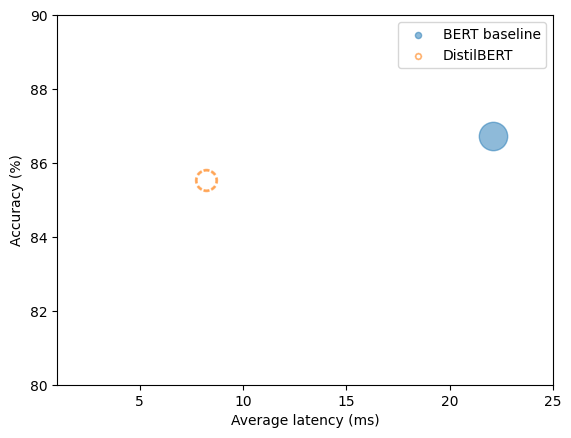

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(perf_metrics, current_optim_type):
 df = pd.DataFrame.from_dict(perf_metrics, orient='index')
 for idx in df.index:
  df_opt = df.loc[idx]
  # Add a dashed circle around the current optimization type
  if idx == current_optim_type:
    plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
      alpha=0.5, s=df_opt["size_mb"], label=idx,
      marker='$◌$')
  else:
    plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
    s=df_opt["size_mb"], label=idx, alpha=0.5)
 legend = plt.legend(bbox_to_anchor=(1,1))
 for handle in legend.legend_handles:
  handle.set_sizes([20])
 plt.ylim(80,90)
 # Use the slowest model to define the x-axis range
 xlim = int(perf_metrics["BERT baseline"]["time_avg_ms"] + 3)
 plt.xlim(1, xlim)
 plt.ylabel("Accuracy (%)")
 plt.xlabel("Average latency (ms)")
 plt.show()

plot_metrics(perf_metrics, optim_type)